# Project: Automated ECG Analysis & Clinical Metric Extraction
**Author:** [Debalina Bhaumik] | **Domain:** Biomedical Engineering & Data Science

### 1. Clinical Objective
The goal of this pipeline is to process raw ambulatory ECG signals to extract **Heart Rate (BPM)**. 
Reliable peak detection is the foundation for diagnosing arrhythmias such as **Tachycardia** and **Bradycardia**.

### 2. Dataset Specification
*   **Source:** MIT-BIH Arrhythmia Database (via PhysioNet).
*   **Sampling Frequency ($f_s$):** 360 Hz.
*   **Signal Type:** Lead II ECG.

### 3. Engineering Strategy & Risk Mitigation
*   **Filtering:** A 5th-order **Butterworth Bandpass Filter (0.5 - 40 Hz)** is implemented. 
    *   *Rationale:* The 0.5 Hz high-pass removes **baseline wander** (respiratory artifacts), while the 40 Hz low-pass removes **EMG noise** and powerline interference.
*   **Validation:** Detection is performed using the **xqrs algorithm**, which is robust against high T-wave morphology that often causes "double-counting" in simpler threshold models.

---



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


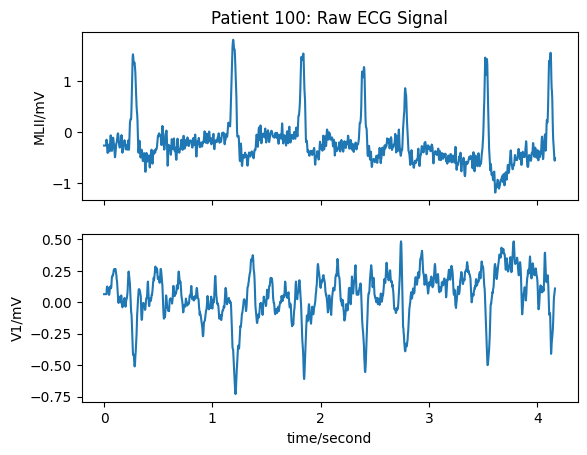

In [1]:

import sys
!{sys.executable} -m pip install wfdb matplotlib

# Step 2: Import the tools
import wfdb
import matplotlib.pyplot as plt

# Step 3: Download and read 5 seconds of an ECG
# '100' is the patient ID from the MIT-BIH Arrhythmia Database
record = wfdb.rdrecord('203' \
'', pn_dir='mitdb', sampto=1500)

# Step 4: Visualize it
wfdb.plot_wfdb(record=record, title='Patient 100: Raw ECG Signal')


Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
Total heartbeats detected: 7


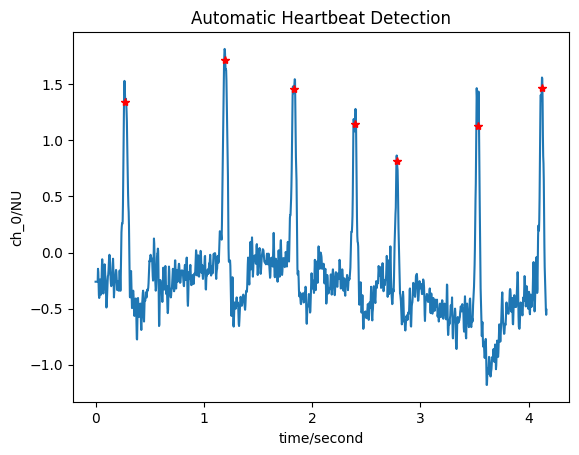

In [2]:
from wfdb import processing

# 1. This algorithm "hunts" for the QRS complex (the main spike of the heartbeat)
# We use the 'record' variable we created in the previous step
peaks = processing.xqrs_detect(sig=record.p_signal[:,0], fs=record.fs)

# 2. Let's see how many beats were found in those 5 seconds
print(f"Total heartbeats detected: {len(peaks)}")

# 3. Plot the signal again, but this time "mark" where the algorithm thinks the beats are
wfdb.plot_items(signal=record.p_signal[:,0], ann_samp=[peaks], 
                title='Automatic Heartbeat Detection',
                time_units='seconds', fs=record.fs)


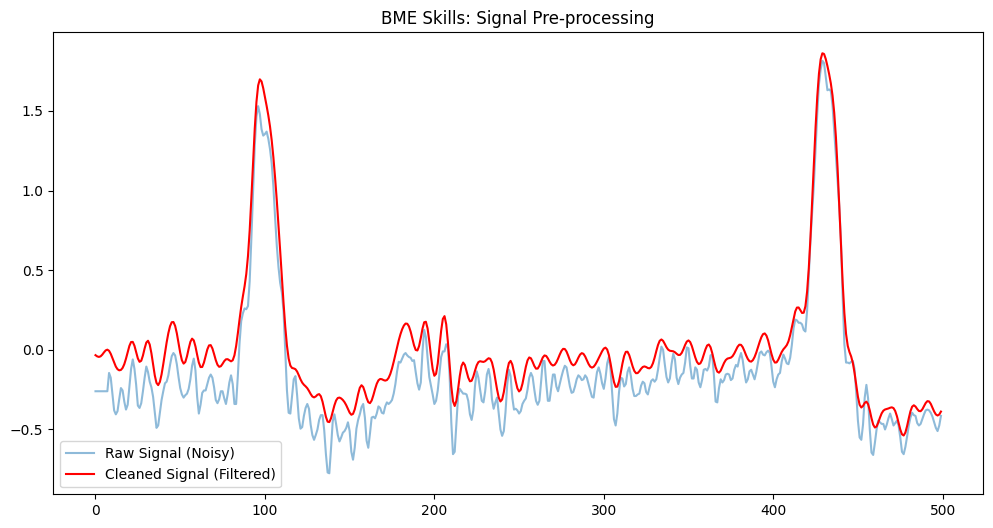

In [3]:
from scipy.signal import butter, filtfilt

# 1. Define the Filter (Standard ECG range is 0.5Hz to 40Hz)
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

# 2. Apply the filter to your 'record' signal
fs = record.fs  # The sampling frequency of the MIT-BIH data
cleaned_signal = butter_bandpass_filter(record.p_signal[:,0], 0.5, 40, fs)

# 3. Compare Raw vs. Cleaned
plt.figure(figsize=(12, 6))
plt.plot(record.p_signal[:500,0], label='Raw Signal (Noisy)', alpha=0.5)
plt.plot(cleaned_signal[:500], label='Cleaned Signal (Filtered)', color='red')
plt.legend()
plt.title("BME Skills: Signal Pre-processing")
plt.show()


In [4]:
# 1. Calculate the distance between peaks (in samples)
import numpy as np
rr_intervals = np.diff(peaks)

# 2. Convert samples to seconds (fs is samples per second)
rr_seconds = rr_intervals / fs

# 3. Calculate BPM (60 seconds / average RR interval)
avg_rr = np.mean(rr_seconds)
bpm = 60 / avg_rr

print(f"Calculated Heart Rate: {bpm:.2f} BPM")

# 4. Clinical Logic
if bpm > 100:
    print("Status: Tachycardia Detected (Clinical Alert)")
elif bpm < 60:
    print("Status: Bradycardia Detected (Clinical Alert)")
else:
    print("Status: Normal Sinus Rhythm")


Calculated Heart Rate: 93.64 BPM
Status: Normal Sinus Rhythm


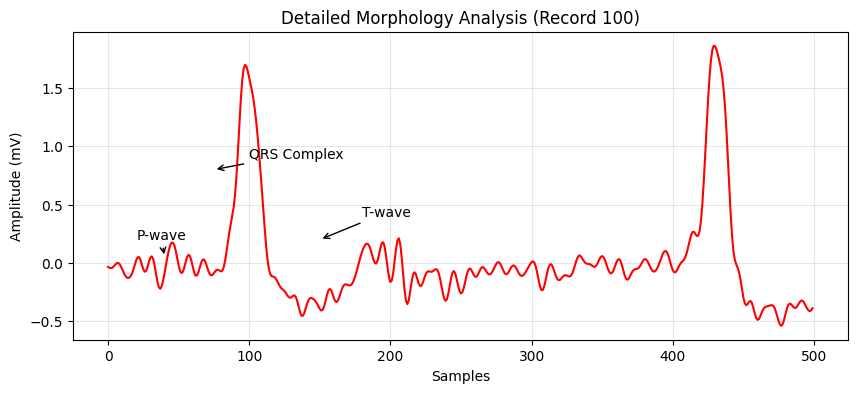

In [5]:
# Create a 'Zoom' to see a single heartbeat in detail
plt.figure(figsize=(10, 4))
# We zoom into the first 1.5 seconds (approx 500 samples)
plt.plot(cleaned_signal[:500], color='red', linewidth=1.5)

# Add clinical labels to show you know the anatomy
plt.annotate('P-wave', xy=(40, 0.05), xytext=(20, 0.2), arrowprops=dict(arrowstyle='->'))
plt.annotate('QRS Complex', xy=(75, 0.8), xytext=(100, 0.9), arrowprops=dict(arrowstyle='->'))
plt.annotate('T-wave', xy=(150, 0.2), xytext=(180, 0.4), arrowprops=dict(arrowstyle='->'))

plt.title("Detailed Morphology Analysis (Record 100)")
plt.xlabel("Samples")
plt.ylabel("Amplitude (mV)")
plt.grid(True, alpha=0.3)
plt.show()

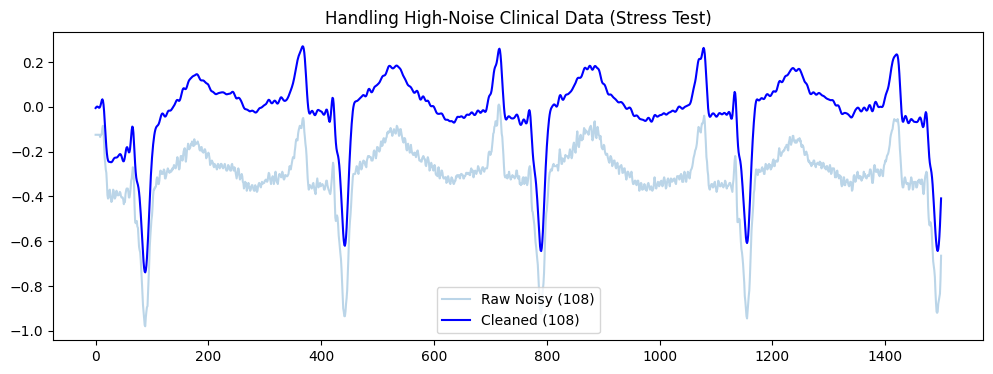

In [6]:
# Testing the pipeline on a known 'Difficult' record (Record 108)
record_noisy = wfdb.rdrecord('108', pn_dir='mitdb', sampto=3000)
# Clean it using your existing filter
cleaned_noisy = butter_bandpass_filter(record_noisy.p_signal[:,0], 0.5, 40, fs)

plt.figure(figsize=(12, 4))
plt.plot(record_noisy.p_signal[:1500,0], alpha=0.3, label='Raw Noisy (108)')
plt.plot(cleaned_noisy[:1500], color='blue', label='Cleaned (108)')
plt.legend()
plt.title("Handling High-Noise Clinical Data (Stress Test)")
plt.show()


In [1]:
import wfdb
import numpy as np
from scipy.signal import butter, filtfilt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Load Data
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=1000)
fs = record.fs
raw_signal = record.p_signal[:, 0]
time_axis = np.arange(len(raw_signal)) / fs

# 2. Apply Filter
b, a = butter(5, [0.5, 40], btype='band', fs=fs)
clean_sig = filtfilt(b, a, raw_signal)

# 3. Create Side-by-Side Subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=("Raw ECG Signal", "Cleaned ECG Signal"))

# 4. Add Raw Signal to Left (Column 1)
fig.add_trace(
    go.Scatter(x=time_axis, y=raw_signal, name="Raw", line=dict(color='gray')),
    row=1, col=1
)

# 5. Add Cleaned Signal to Right (Column 2)
fig.add_trace(
    go.Scatter(x=time_axis, y=clean_sig, name="Cleaned", line=dict(color='red')),
    row=1, col=2
)

# 6. Update Layout
fig.update_layout(
    title="Side-by-Side DSP Analysis",
    template="plotly_white",
    showlegend=False
)

fig.show()


### 📊 Interactive Data Visualization
To enhance clinical analysis, I transitioned from static Matplotlib plots to interactive Plotly graphics. 

**Why this adds value:**
- **Dynamic Zooming:** Clinicians can zoom directly onto specific QRS complexes.
- **Data Inspection:** Hovering reveals exact millivolt values at specific timestamps.
- **Pro Layout:** Side-by-side subplots directly compare raw and processed data.


In [2]:
%pip install nbformat


   -------------------------- ------------- 4/6 [jsonschema]
   --------------------------------- ------ 5/6 [nbformat]
   ---------------------------------------- 6/6 [nbformat]

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import wfdb
import numpy as np
from scipy.signal import butter, filtfilt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Load Data
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=1000)
fs = record.fs
raw_signal = record.p_signal[:, 0]
time_axis = np.arange(len(raw_signal)) / fs

# 2. Apply Filter
b, a = butter(5, [0.5, 40], btype='band', fs=fs)
clean_sig = filtfilt(b, a, raw_signal)

# 3. Create Side-by-Side Subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=("Raw ECG Signal", "Cleaned ECG Signal"))

# 4. Add Raw Signal to Left
fig.add_trace(
    go.Scatter(x=time_axis, y=raw_signal, name="Raw", line=dict(color='gray')),
    row=1, col=1
)

# 5. Add Cleaned Signal to Right
fig.add_trace(
    go.Scatter(x=time_axis, y=clean_sig, name="Cleaned", line=dict(color='red')),
    row=1, col=2
)

# 6. Update Layout and MATCH X-AXES
fig.update_layout(
    title="Side-by-Side DSP Analysis (Synced Zoom)",
    template="plotly_white",
    showlegend=False
)

# This line forces both subplots to share zoom levels
fig.update_xaxes(matches='x')

fig.show()


* **Interactive UI:** Used Plotly to build interactive, zoomable ECG visualizations.
* **Dual View:** Side-by-side layout for instant visual verification of DSP filters.
